### Code for estimating 'state of hyrdogen' in PEM cell

In [82]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


DATA_DIR = Path("../../data/PEM_test/charge_discharge")
READINGS_PATH = Path("../../data/PEM_test/volume_readings/readings.csv")

FULL_CHARGE_FILE = "discharge_PEM_full.csv"
FULL_CHARGE_VOLUME_ML = 15.6

#correcttion factors for current and voltage measurements, based on the calibration data
CURRENT_CORRECTION = {
    0x40: lambda i: i + 0.000563,
    0x41: lambda i: i - 0.000033,
    0x44: lambda i: i + 0.000138,
    0x45: lambda i: 0.843 * i + 0.001,
}

VOLTAGE_CORRECTION = {
    0x40: lambda v: v - 0.068,
    0x41: lambda v: v - 0.066,
    0x44: lambda v: v - 0.180,
    0x45: lambda v: v - 0.064,
}

#### Data treatment

In [83]:
# Read data files 
charge_test_files = [
    "discharge_020A_30s_r1.csv",
    "discharge_020A_60s_r1.csv",
    "discharge_020A_120s_r1.csv",
    "discharge_030A_30s_r1.csv",
    "discharge_030A_60s_r1.csv",
    "discharge_030A_120s_r1.csv",
    "discharge_040A_30s_r1.csv",
    "discharge_040A_60s_r1.csv",
    "discharge_040A_120s_r1.csv",
]

readings = pd.read_csv(READINGS_PATH)

readings["current_A"] = readings["current_A"].astype(float)
readings["time_s"] = readings["time_s"].astype(float)
readings["volume_mL"] = readings["volume_mL"].astype(float)

print(readings)


   current_A  time_s  volume_mL
0        0.2    30.0        0.2
1        0.2    60.0        1.6
2        0.2   120.0        3.0
3        0.3    30.0        1.6
4        0.3    60.0        2.2
5        0.3   120.0        4.2
6        0.4    30.0        2.2
7        0.4    60.0        4.0
8        0.4   120.0        6.0


In [84]:
def parse_charge_test_name(file_name):
    parts = file_name.replace(".csv", "").split("_")
    
    current_A = int(parts[1].replace("A", "")) / 100
    time_s = int(parts[2].replace("s", ""))
    
    return current_A, time_s


def load_and_correct_file(file_name):
    path = DATA_DIR / file_name
    
    df = pd.read_csv(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp").reset_index(drop=True)
    
    df["time_s"] = (
        df["timestamp"] - df["timestamp"].iloc[0]
    ).dt.total_seconds()
    
    df["dt_s"] = df["timestamp"].diff().dt.total_seconds().fillna(0)
    
    df["dc_current_A"] = CURRENT_CORRECTION[0x44](
        df["ina3_current_mA"] / 1000
    )
    
    df["dc_voltage_V"] = VOLTAGE_CORRECTION[0x44](
        df["ina3_bus_V"]
    )
    
    df["pem_current_A"] = CURRENT_CORRECTION[0x45](
        df["ina4_current_mA"] / 1000
    )
    
    df["pem_voltage_V"] = VOLTAGE_CORRECTION[0x45](
        df["ina4_bus_V"]
    )
    
    df["pem_power_W"] = df["pem_voltage_V"] * df["pem_current_A"]
    
    return df


def extract_charge_part(df, expected_time_s=None, power_threshold_W=0.02, drop_fraction=0.5):
    charge_df = df[df["scenario"] == 3].copy()
    charge_df = charge_df.sort_values("timestamp").reset_index(drop=True)
    
    active = charge_df["pem_power_W"] > power_threshold_W
    
    if not active.any():
        return charge_df.iloc[0:0].copy()
    
    start_idx = active.idxmax()
    
    charge = charge_df.loc[start_idx:].copy()
    charge = charge.reset_index(drop=True)
    
    steady_power = charge["pem_power_W"].max()
    collapse_threshold = drop_fraction * steady_power
    
    collapse = charge["pem_power_W"] < collapse_threshold
    collapse.iloc[0:5] = False
    
    if collapse.any():
        end_idx = collapse.idxmax()
        charge = charge.loc[:end_idx - 1].copy()
    
    if expected_time_s is not None:
        start_time = charge["time_s"].iloc[0]
        end_time = start_time + expected_time_s
        
        charge = charge[
            (charge["time_s"] >= start_time)
            & (charge["time_s"] <= end_time)
        ].copy()
    
    charge = charge.reset_index(drop=True)
    
    charge["dt_s"] = (
        charge["timestamp"]
        .diff()
        .dt.total_seconds()
        .fillna(0)
    )
    
    charge["time_charge_s"] = (
        charge["timestamp"] - charge["timestamp"].iloc[0]
    ).dt.total_seconds()
    
    return charge

In [85]:
charge_results = []

for file_name in charge_test_files:
    expected_current_A, expected_time_s = parse_charge_test_name(file_name)
    
    df = load_and_correct_file(file_name)
    charge = extract_charge_part(df, expected_time_s=expected_time_s)
    
    charge["dQ_C"] = charge["pem_current_A"] * charge["dt_s"]
    
    Q_charge = charge["dQ_C"].sum()
    
    H2_theoretical_mL = Q_charge / (z * F) * Vm
    
    charge_results.append({
        "file": file_name,
        "test_type": "short duration",
        "current_A": expected_current_A,
        "time_s": expected_time_s,
        "actual_duration_s": charge["dt_s"].sum(),
        "Q_charge_C": Q_charge,
        "H2_theoretical_mL": H2_theoretical_mL,
        "mean_current_A": charge["pem_current_A"].mean(),
        "mean_voltage_V": charge["pem_voltage_V"].mean(),
        "mean_power_W": charge["pem_power_W"].mean()
    })

charge_results = pd.DataFrame(charge_results)

charge_results = charge_results.merge(
    readings,
    on=["current_A", "time_s"],
    how="left"
)

print(charge_results)

                         file       test_type  current_A  time_s  \
0   discharge_020A_30s_r1.csv  short duration        0.2      30   
1   discharge_020A_60s_r1.csv  short duration        0.2      60   
2  discharge_020A_120s_r1.csv  short duration        0.2     120   
3   discharge_030A_30s_r1.csv  short duration        0.3      30   
4   discharge_030A_60s_r1.csv  short duration        0.3      60   
5  discharge_030A_120s_r1.csv  short duration        0.3     120   
6   discharge_040A_30s_r1.csv  short duration        0.4      30   
7   discharge_040A_60s_r1.csv  short duration        0.4      60   
8  discharge_040A_120s_r1.csv  short duration        0.4     120   

   actual_duration_s  Q_charge_C  H2_theoretical_mL  mean_current_A  \
0               30.0    5.999283           0.746138        0.199971   
1               60.0   11.999809           1.492431        0.199995   
2              118.0   23.635698           2.939601        0.200300   
3               29.0    8.699508   

In [ ]:
df_full = load_and_correct_file(FULL_CHARGE_FILE)

charge_full = extract_charge_part(
    df_full,
    expected_time_s=None
)

charge_full["dQ_C"] = (
    charge_full["pem_current_A"]
    * charge_full["dt_s"]
)

# Calculate total charge for the full charge test
Q_charge_full = charge_full["dQ_C"].sum()


#Faradays constant
F = 96485.3329
z = 2
Vm = 24000

H2_theoretical_full_mL = (
    Q_charge_full
    / (z * F)
    * Vm
)

full_result = pd.DataFrame([{
    "file": FULL_CHARGE_FILE,
    "test_type": "full charge",
    "current_A": charge_full["pem_current_A"].mean(),
    "time_s": charge_full["dt_s"].sum(),
    "actual_duration_s": charge_full["dt_s"].sum(),
    "Q_charge_C": Q_charge_full,
    "H2_theoretical_mL": H2_theoretical_full_mL,
    "mean_current_A": charge_full["pem_current_A"].mean(),
    "mean_voltage_V": charge_full["pem_voltage_V"].mean(),
    "mean_power_W": charge_full["pem_power_W"].mean(),
    "volume_mL": FULL_CHARGE_VOLUME_ML
}])

print(full_result)

                     file    test_type  current_A  time_s  actual_duration_s  \
0  discharge_PEM_full.csv  full charge   0.142345  1082.0             1082.0   

   Q_charge_C  H2_theoretical_mL  mean_current_A  mean_voltage_V  \
0  154.023675          19.156115        0.142345        1.428898   

   mean_power_W  volume_mL  
0      0.203392       15.6  


In [87]:
charge_results_all = pd.concat(
    [charge_results, full_result],
    ignore_index=True
)

charge_results_all["eta_charge"] = (
    charge_results_all["volume_mL"]
    / charge_results_all["H2_theoretical_mL"]
)

print(charge_results_all)

                         file       test_type  current_A  time_s  \
0   discharge_020A_30s_r1.csv  short duration   0.200000    30.0   
1   discharge_020A_60s_r1.csv  short duration   0.200000    60.0   
2  discharge_020A_120s_r1.csv  short duration   0.200000   120.0   
3   discharge_030A_30s_r1.csv  short duration   0.300000    30.0   
4   discharge_030A_60s_r1.csv  short duration   0.300000    60.0   
5  discharge_030A_120s_r1.csv  short duration   0.300000   120.0   
6   discharge_040A_30s_r1.csv  short duration   0.400000    30.0   
7   discharge_040A_60s_r1.csv  short duration   0.400000    60.0   
8  discharge_040A_120s_r1.csv  short duration   0.400000   120.0   
9      discharge_PEM_full.csv     full charge   0.142345  1082.0   

   actual_duration_s  Q_charge_C  H2_theoretical_mL  mean_current_A  \
0               30.0    5.999283           0.746138        0.199971   
1               60.0   11.999809           1.492431        0.199995   
2              118.0   23.635698      

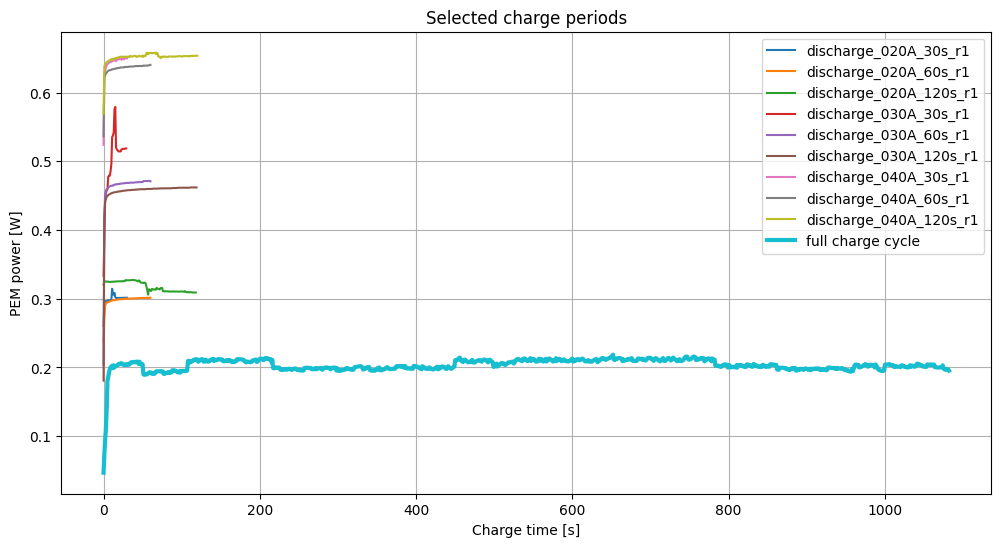

In [88]:
plt.figure(figsize=(12, 6))

for file_name in charge_test_files:
    expected_current_A, expected_time_s = parse_charge_test_name(file_name)
    
    df = load_and_correct_file(file_name)
    charge = extract_charge_part(df, expected_time_s=expected_time_s)
    
    plt.plot(
        charge["time_charge_s"],
        charge["pem_power_W"],
        label=file_name.replace(".csv", "")
    )

plt.plot(
    charge_full["time_charge_s"],
    charge_full["pem_power_W"],
    linewidth=3,
    label="full charge cycle"
)

plt.xlabel("Charge time [s]")
plt.ylabel("PEM power [W]")
plt.title("Selected charge periods")
plt.grid(True)
plt.legend()
plt.show()

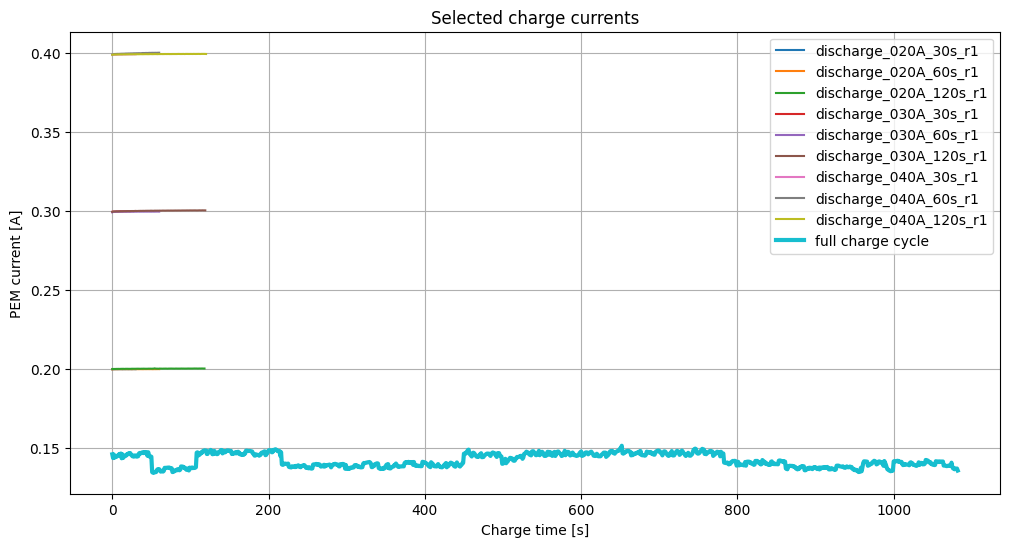

In [89]:
plt.figure(figsize=(12, 6))

for file_name in charge_test_files:
    expected_current_A, expected_time_s = parse_charge_test_name(file_name)
    df = load_and_correct_file(file_name)
    charge = extract_charge_part(df, expected_time_s=expected_time_s)

    plt.plot(
        charge["time_charge_s"],
        charge["pem_current_A"],
        label=file_name.replace(".csv", "")
    )

plt.plot(
    charge_full["time_charge_s"],
    charge_full["pem_current_A"],
    linewidth=3,
    label="full charge cycle"
)

plt.xlabel("Charge time [s]")
plt.ylabel("PEM current [A]")
plt.title("Selected charge currents")
plt.grid(True)
plt.legend()
plt.show()

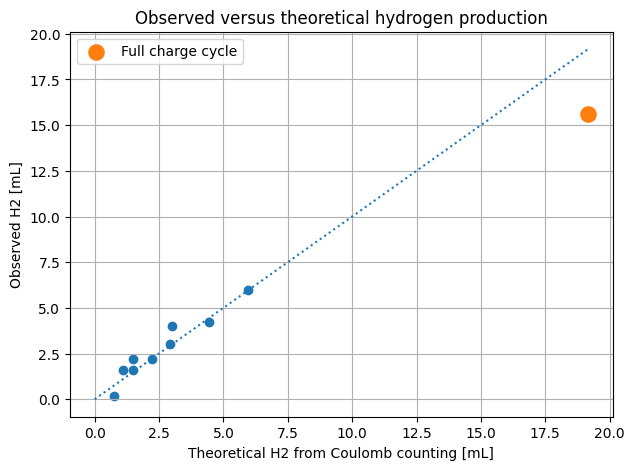

In [90]:
plt.figure(figsize=(7, 5))

plt.scatter(
    charge_results_all["H2_theoretical_mL"],
    charge_results_all["volume_mL"]
)

full_point = charge_results_all[
    charge_results_all["test_type"] == "full charge"
]

plt.scatter(
    full_point["H2_theoretical_mL"],
    full_point["volume_mL"],
    s=120,
    label="Full charge cycle"
)

max_value = max(
    charge_results_all["H2_theoretical_mL"].max(),
    charge_results_all["volume_mL"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle=":"
)

plt.xlabel("Theoretical H2 from Coulomb counting [mL]")
plt.ylabel("Observed H2 [mL]")
plt.title("Observed versus theoretical hydrogen production")
plt.grid(True)
plt.legend()
plt.show()

In [91]:
charge_results_valid = charge_results_all[
    charge_results_all["eta_charge"].between(0.8, 1.6)
].copy()

eta_charge_valid = charge_results_valid["eta_charge"].mean()
eta_charge_valid_std = charge_results_valid["eta_charge"].std()

H2_CHARGE_FACTOR_ML_PER_C = (
    eta_charge_valid
    * Vm
    / (z * F)
)

print(charge_results_valid[[
    "file",
    "test_type",
    "H2_theoretical_mL",
    "volume_mL",
    "eta_charge"
]])

print(f"\nMean charge correction factor: {eta_charge_valid:.3f}")
print(f"Standard deviation: {eta_charge_valid_std:.3f}")
print(f"Hydrogen charge factor: {H2_CHARGE_FACTOR_ML_PER_C:.8f} mL/C")

print("\nEMS charge estimate:")
print(f"H2_next_mL = H2_now_mL + {H2_CHARGE_FACTOR_ML_PER_C:.8f} * I_charge_A * dt_s")

                         file       test_type  H2_theoretical_mL  volume_mL  \
1   discharge_020A_60s_r1.csv  short duration           1.492431        1.6   
2  discharge_020A_120s_r1.csv  short duration           2.939601        3.0   
3   discharge_030A_30s_r1.csv  short duration           1.081969        1.6   
4   discharge_030A_60s_r1.csv  short duration           2.236670        2.2   
5  discharge_030A_120s_r1.csv  short duration           4.444704        4.2   
6   discharge_040A_30s_r1.csv  short duration           1.489911        2.2   
7   discharge_040A_60s_r1.csv  short duration           2.985072        4.0   
8  discharge_040A_120s_r1.csv  short duration           5.962330        6.0   
9      discharge_PEM_full.csv     full charge          19.156115       15.6   

   eta_charge  
1    1.072076  
2    1.020547  
3    1.478786  
4    0.983605  
5    0.944945  
6    1.476598  
7    1.340001  
8    1.006318  
9    0.814361  

Mean charge correction factor: 1.126
Standard de

In [92]:
# EMS hydrogen state estimation during electrolysis

# Hydrogen state [mL]
H2_ml = 0.0

# Maximum measured hydrogen storage [mL]
H2_max_ml = 15.6

# Charge calibration factor from valid short tests
eta_charge = 1.165

# Faraday based hydrogen factor [mL/C]
H2_charge_factor_ml_per_C = (
    eta_charge
    * Vm
    / (z * F)
)

print(f"Hydrogen charge factor: {H2_charge_factor_ml_per_C:.8f} mL/C")

Hydrogen charge factor: 0.14489249 mL/C
